In [1]:
import sys
from pathlib import Path
sys.path.append("/export/home/mickler/boa")

import hydra
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
import torch

from boa.model.module import ChgLightningModule

run_path = Path("/export/scratch/mklockow/boa/models/train/runs/437_qm9_small_qm9_vasp_small__seed-2")
best_ckpt = (run_path / "best_model_path.txt").read_text().strip()
model_path = run_path / best_ckpt
config_path = run_path / "config.yaml"

cfg = OmegaConf.load(config_path)
# datamodule = hydra.utils.instantiate(cfg.data.datamodule, _recursive_=False)
# datamodule.setup("fit")
# val_set = datamodule.val_dataset
# sample = val_set[0]
# sample

In [2]:
def plot_radial_part(gto, distances):
    radial, correction, corrected_radial = gto.compute_radial(distances.unsqueeze(1))
    fig, axes = plt.subplots(4, 8, figsize=(20, 10), sharex=True)
    axes = axes.flatten()

    for i in range(32):
        axes[i].plot(distances.numpy(force=True), radial[:, i].numpy(force=True), label='Base', alpha=0.7)
        axes[i].plot(distances.numpy(force=True), corrected_radial[:, i].numpy(force=True), label='Corrected', alpha=0.7)
        axes[i].set_title(f'L={gto.Ls[i]}, exp={gto.expos[i]:.2g}')
        axes[i].set_xlabel('Distance')
        axes[i].set_ylabel('Amplitude')
        axes[i].grid(True, alpha=0.3)
        if i == 0:  # Add legend only to first subplot to avoid clutter
            axes[i].legend()

    plt.tight_layout()
    plt.show()

In [3]:
z = 8
model = ChgLightningModule.load_from_checkpoint(model_path)

Unique atom types: [1 6 7 8 9]
Using radial correction for GTOs.
Using radial correction for GTOs.
Using radial correction for GTOs.
Using radial correction for GTOs.
Using radial correction for GTOs.


/export/home/mickler/boa/boa/model/module.py:124: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(gto.contraction, dtype=torch.int64),


BOA(
  (boa_stack): BoaBlockStack(
    (blocks): ModuleList(
      (0-3): 4 x BoaBlock(
        (linear0): StableLinearNodeOperator(
          (stable_linear_node_operators): ModuleDict(
            (1): StableLinearNodeOperatorAtom(
              (linear1): Linear(7x0e+4x1o+2x2e+1x3o -> 7x0e+4x1o+2x2e+1x3o | 70 weights)
            )
            (6): StableLinearNodeOperatorAtom(
              (linear1): Linear(16x0e+8x1o+4x2e+2x3o+1x4e -> 16x0e+8x1o+4x2e+2x3o+1x4e | 341 weights)
            )
            (7): StableLinearNodeOperatorAtom(
              (linear1): Linear(16x0e+8x1o+4x2e+2x3o+1x4e -> 16x0e+8x1o+4x2e+2x3o+1x4e | 341 weights)
            )
            (8): StableLinearNodeOperatorAtom(
              (linear1): Linear(16x0e+9x1o+4x2e+2x3o+1x4e -> 16x0e+9x1o+4x2e+2x3o+1x4e | 358 weights)
            )
            (9): StableLinearNodeOperatorAtom(
              (linear1): Linear(16x0e+9x1o+4x2e+2x3o+1x4e -> 16x0e+9x1o+4x2e+2x3o+1x4e | 358 weights)
            )
          )

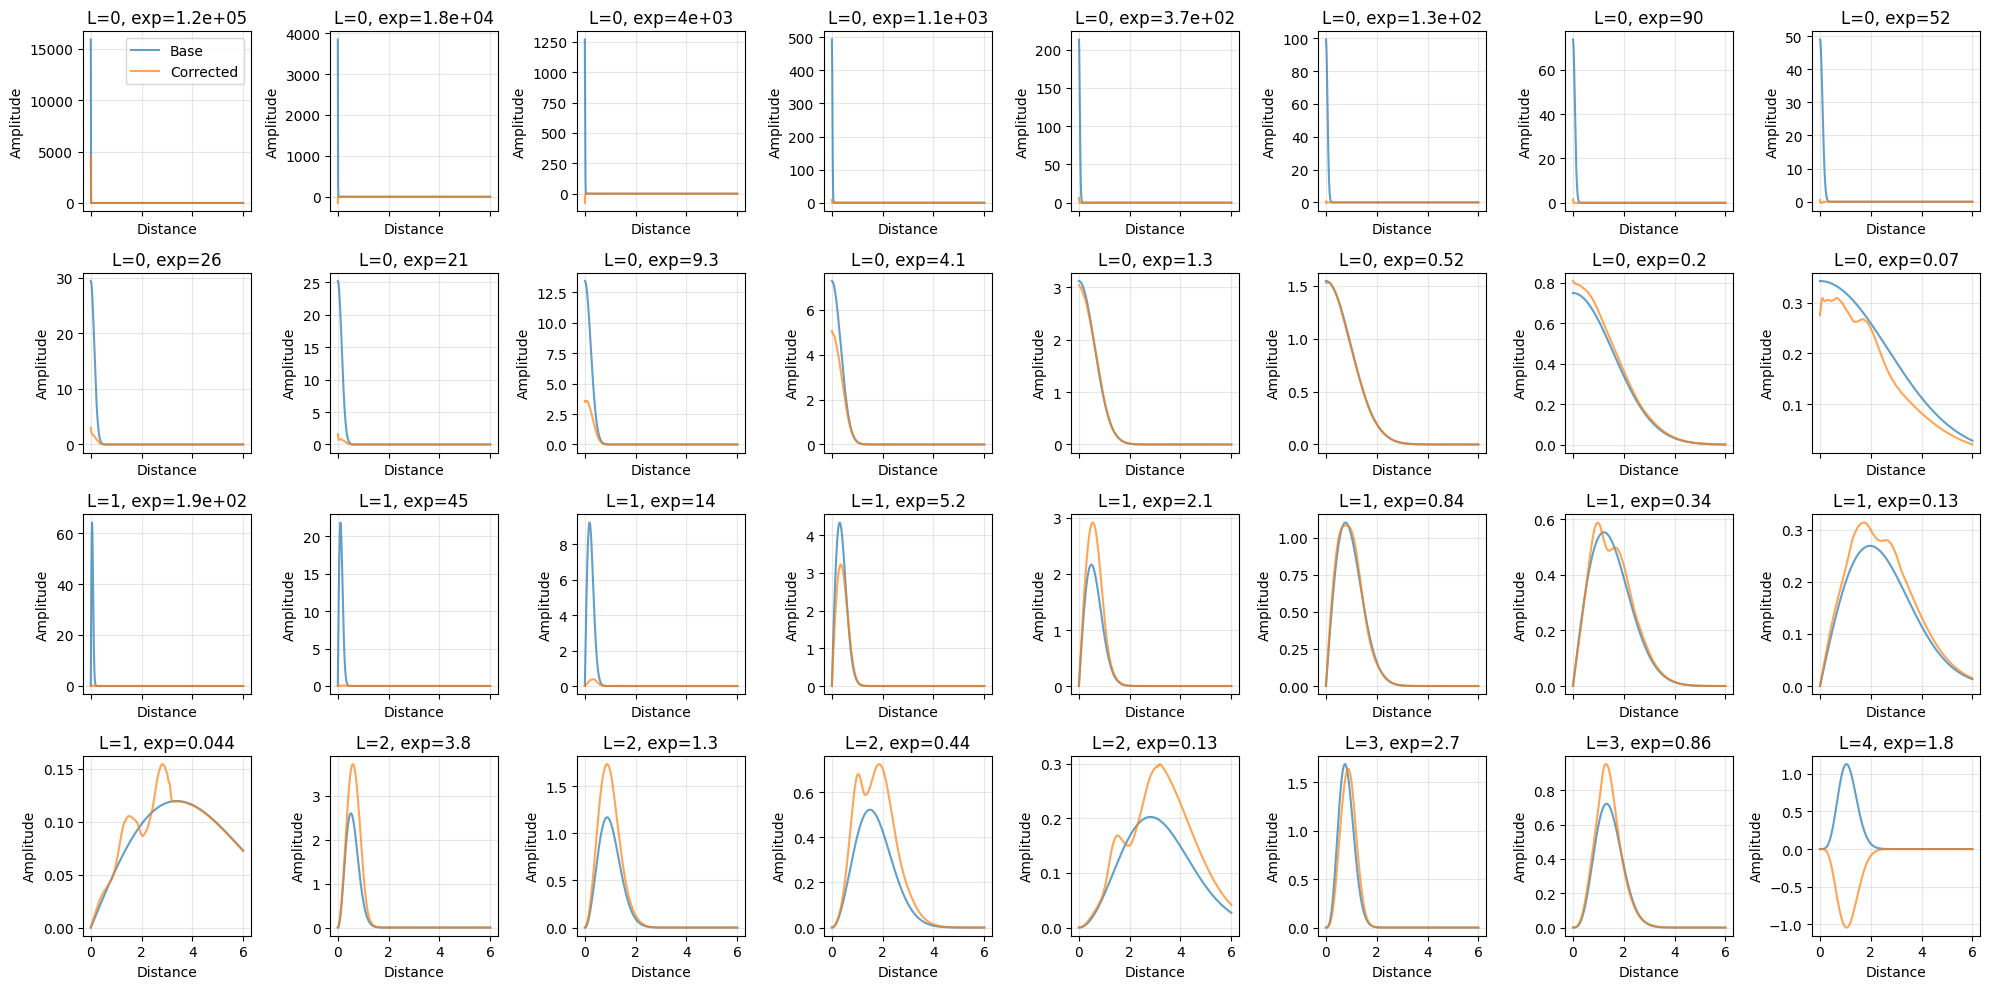

In [4]:
distances = torch.linspace(0.0001, 6, 501, device=model.device)
gto = model.gto_dict[str(z)]
plot_radial_part(gto, distances)

# Analysis of Normalization Issue

Your current approach integrates only along the radial direction from 0 to 10, but GTOs are 3D functions. The normalization condition for a GTO is:

∫∫∫ |ψ(r)|² dV = 1

In spherical coordinates, this becomes:
∫₀^∞ ∫₀^π ∫₀^{2π} |R(r)|² |Y_l^m(θ,φ)|² r² sin(θ) dr dθ dφ = 1

Since spherical harmonics are normalized: ∫∫ |Y_l^m(θ,φ)|² sin(θ) dθ dφ = 1

The radial part must satisfy: ∫₀^∞ |R(r)|² r² dr = 1

So we need to multiply by r² and integrate from 0 to ∞, not just sum the function values.

In [18]:
def compute_correct_gauss_norm(gto):
    """
    Compute the correct normalization integral for GTOs.
    For a radial function R(r), the normalization condition is:
    ∫₀^∞ |R(r)|² r² dr = 1
    """
    # Use a wider range and more points for better integration
    r = torch.linspace(0.0000001, 15, 20000, device=model.device)
    dr = r[1] - r[0]
    
    # Compute radial parts
    radial, correction, corrected_radial = gto.compute_radial(r.unsqueeze(1))
    
    # Proper normalization integral: ∫ |R(r)|² r² dr
    # Note: r² factor is crucial for 3D spherical integration
    r_squared = r.unsqueeze(1) ** 2  # Shape: (5000, 1)
    
    # For the base radial functions
    radial_norm_integrand = radial ** 2 * r_squared
    radial_integrals = torch.trapz(radial_norm_integrand, r, dim=0)
    
    # For the corrected radial functions  
    corrected_norm_integrand = corrected_radial ** 2 * r_squared
    corrected_integrals = torch.trapz(corrected_norm_integrand, r, dim=0)
    
    print("=== Normalization Check ===")
    print(f"Base radial integrals (should be ~1): {radial_integrals}")
    print(f"Mean base integral: {radial_integrals.mean():.6f}")
    print(f"Std base integral: {radial_integrals.std():.6f}")
    print()
    print(f"Corrected radial integrals: {corrected_integrals}")
    print(f"Mean corrected integral: {corrected_integrals.mean():.6f}")
    print(f"Std corrected integral: {corrected_integrals.std():.6f}")
    
    return radial_integrals, corrected_integrals

# Run the correct normalization check
base_norms, corrected_norms = compute_correct_gauss_norm(gto)

=== Normalization Check ===
Base radial integrals (should be ~1): tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000], device='cuda:0')
Mean base integral: 1.000000
Std base integral: 0.000000

Corrected radial integrals: tensor([8.8500e-02, 3.9685e-04, 1.2942e-03, 1.9245e-05, 2.8196e-05, 3.2338e-06,
        8.2164e-06, 3.8781e-05, 1.0245e-02, 4.4285e-03, 1.3798e-01, 5.9457e-01,
        1.0105e+00, 9.7753e-01, 1.1441e+00, 6.5979e-01, 6.6700e-06, 4.9354e-05,
        4.9648e-03, 7.5194e-01, 1.8983e+00, 1.0347e+00, 1.1013e+00, 1.3179e+00,
        1.0354e+00, 2.6807e+00, 2.0356e+00, 2.3208e+00, 2.0846e+00, 1.2066e+00,
        1.3559e+00, 9.4522e-01], device='cuda:0', grad_fn=<DivBackward1>)
Mean corrected integral: 0.762604
Std corrected integral: 0.803259
